# 05 · Modeling — baseline vs LightGBM dengan validasi walk-forward
Fase CRISP-DM 4: **Select modeling technique → Generate test design → Build model → Assess model**.

| Model | Jenis | Ide | Kenapa dipakai |
|---|---|---|---|
| Naive **"harga minggu lalu"** | Aturan | Skor = kenaikan 7 hari terakhir (tren minggu lalu berlanjut) | Baseline paling sederhana, dipakai praktisi |
| **Seasonal naive** | Aturan | Skor = kenaikan 14 hari yang terjadi tahun lalu di periode yang sama | Menguji apakah pola musiman saja cukup |
| **SARIMA** (ARIMA + Fourier) | Deret waktu klasik | Ramal log harga mingguan 1–2 minggu, hitung peluang naik > ambang | Baseline statistik standar per seri |
| **Regresi logistik** | ML linear | Fitur yang sama dengan LightGBM | Memisahkan efek "fitur" vs "model non-linear" |
| **LightGBM** | Gradient boosting trees | 74+ fitur, 1 model global untuk semua provinsi & komoditas | Model utama: menangani non-linearitas, interaksi, nilai kosong |

Catatan desain: satu model **global** (bukan 700 model per seri) supaya kejadian langka di satu seri bisa "belajar" dari seri lain; identitas komoditas/provinsi masuk sebagai fitur kategori.

In [1]:
# --- Setup: path project, modul radarpangan, gaya grafik -----------------------------------
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from radarpangan.config import load_project
cfg, P = load_project(ROOT)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 10})
print("Project:", ROOT)

Project: /home/claude/MiningProcess


In [2]:
import time, copy
from radarpangan.pipeline import load_refs, feature_columns, load_panel, lgbm_params
from radarpangan.validation import make_folds, modeling_frame, run_walk_forward
from radarpangan.models import sarima_fold_scores
from radarpangan.labeling import threshold_per_column
from radarpangan.metrics import pr_auc, best_threshold
from radarpangan.viz import MODEL_COLORS, PALETTE

refs = load_refs(P)
feats = pd.read_parquet(P.processed / "features.parquet")
groups = json.loads((P.processed / "feature_groups.json").read_text(encoding="utf-8"))
data = modeling_frame(feats); del feats
fcols = feature_columns(data, groups)
print(f"Baris model: {len(data):,} | fitur: {len(fcols)} | proporsi positif: {data['y'].mean():.2%}")

Baris model: 1,451,057 | fitur: 78 | proporsi positif: 5.60%


## 5.1 Desain pengujian: walk-forward dengan *purging*

```
|<------------ fit (latih) ------------>|purge|<-- val 120 hari -->|purge|<-- uji 3 bulan -->|  -> geser 3 bulan
                                        14 hr                      14 hr T_k
```
- **fit**: melatih model. **val**: early stopping LightGBM + memilih ambang alarm (maks. F1). **uji**: prediksi *out-of-sample*.
- **purge 14 hari**: label `y(t)` melihat harga sampai `t+14`, jadi data latih harus berhenti 14 hari sebelum periode berikutnya.
- Uji pertama Jan 2022 (latih awal 2018–2021), lalu maju per 3 bulan sampai data terbaru → ± 19 fold, ± 4,7 tahun periode uji.

,fold,fit_end,val_start,val_end,test_start,test_end
0,0,2021-08-05,2021-08-20,2021-12-17,2022-01-01,2022-03-31
1,1,2021-11-03,2021-11-18,2022-03-17,2022-04-01,2022-06-30
2,2,2022-02-02,2022-02-17,2022-06-16,2022-07-01,2022-09-30
3,3,2022-05-05,2022-05-20,2022-09-16,2022-10-01,2022-12-31
4,4,2022-08-05,2022-08-20,2022-12-17,2023-01-01,2023-03-31
5,5,2022-11-03,2022-11-18,2023-03-17,2023-04-01,2023-06-30
6,6,2023-02-02,2023-02-17,2023-06-16,2023-07-01,2023-09-30
7,7,2023-05-05,2023-05-20,2023-09-16,2023-10-01,2023-12-31
8,8,2023-08-05,2023-08-20,2023-12-17,2024-01-01,2024-03-31
9,9,2023-11-04,2023-11-19,2024-03-17,2024-04-01,2024-06-30


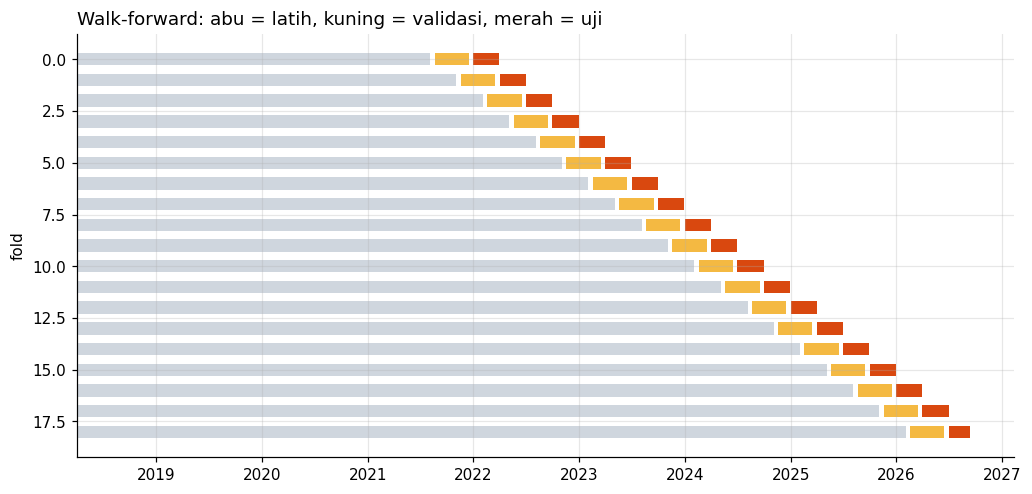

In [3]:
folds = make_folds(data["date"], cfg)
display(folds)
fig, ax = plt.subplots(figsize=(11, 5))
for f in folds.itertuples():
    ax.barh(f.fold, (f.fit_end - pd.Timestamp("2018-04-01")).days, left=pd.Timestamp("2018-04-01"), color="#cfd6de", height=.6)
    ax.barh(f.fold, (f.val_end - f.val_start).days, left=f.val_start, color=PALETTE["watch"], height=.6)
    ax.barh(f.fold, (f.test_end - f.test_start).days, left=f.test_start, color=PALETTE["high"], height=.6)
ax.invert_yaxis(); ax.set_ylabel("fold"); ax.set_title("Walk-forward: abu = latih, kuning = validasi, merah = uji", loc="left")
fig.savefig(P.figures / "fig_05_01_walk_forward.png", dpi=160, bbox_inches="tight"); plt.show()

## 5.2 Tuning hyperparameter LightGBM (hanya data sebelum 2022)
Kandidat parameter dibandingkan dengan walk-forward **semu** yang periode ujinya Jul 2020 – Des 2021 — seluruhnya **sebelum** periode uji utama, sehingga pemilihan parameter tidak "mengintip" data uji.

In [4]:
RUN_TUNING = True
leaders_end = pd.Timestamp(cfg["validation"]["first_test_start"]) - pd.Timedelta(days=cfg["validation"]["purge_days"] + 1)
tune_cfg = copy.deepcopy(cfg); tune_cfg["validation"]["first_test_start"] = "2020-07-01"
tf = make_folds(data["date"], tune_cfg)
tf = tf[tf["test_start"] < leaders_end].copy(); tf["test_end"] = tf["test_end"].clip(upper=leaders_end)
base = dict(cfg["model"]["lgbm"])
candidates = {
    "A: leaves63 mcs200 (config)": {},
    "B: leaves31 mcs500 ff0.7": {"num_leaves": 31, "min_child_samples": 500, "feature_fraction": 0.7},
    "C: leaves127 mcs100": {"num_leaves": 127, "min_child_samples": 100},
    "D: leaves63 mcs1000 ff0.6 l2=5": {"min_child_samples": 1000, "feature_fraction": 0.6, "lambda_l2": 5.0},
    "E: leaves15 mcs300": {"num_leaves": 15, "min_child_samples": 300},
    "F: lr0.03 leaves63 mcs300 ff0.7 l2=3": {"learning_rate": 0.03, "min_child_samples": 300, "feature_fraction": 0.7, "lambda_l2": 3.0},
}
tune_rows = []
if RUN_TUNING:
    for name, over in candidates.items():
        t0 = time.time()
        pr, inf = run_walk_forward(data, fcols, tune_cfg, folds=tf, use_models=("lgbm",), lgbm_params={**base, **over}, verbose=False)
        per_fold = pr.groupby("fold").apply(lambda g: pr_auc(g["y"], g["score_lgbm"]))
        tune_rows.append({"kandidat": name, "PR-AUC rata2 fold": per_fold.mean(), "PR-AUC gabungan": pr_auc(pr["y"], pr["score_lgbm"]),
                          "rata2 iterasi": inf["lgbm_best_iter"].mean(), "detik": round(time.time() - t0)})
    tune = pd.DataFrame(tune_rows).sort_values("PR-AUC rata2 fold", ascending=False)
    display(tune)
    best_name = tune.iloc[0]["kandidat"]
    best = {**base, **candidates[best_name]}
    (P.models / "lgbm_best_params.json").write_text(json.dumps(best, indent=1))
    tune.to_csv(P.tables / "05_tuning_lightgbm.csv", index=False)
    print("Parameter terpilih:", best_name)
params = lgbm_params(cfg, P)
print(params)

,kandidat,PR-AUC rata2 fold,PR-AUC gabungan,rata2 iterasi,detik
5,F: lr0.03 leaves63 mcs300 ff0.7 l2=3,0.4666,0.4578,127.0000,81
1,B: leaves31 mcs500 ff0.7,0.4634,0.4601,103.5000,63
4,E: leaves15 mcs300,0.4614,0.4589,142.6667,58
0,A: leaves63 mcs200 (config),0.4596,0.4585,79.1667,66
2,C: leaves127 mcs100,0.4575,0.4520,67.5000,79
3,D: leaves63 mcs1000 ff0.6 l2=5,0.4529,0.4415,125.0000,80


Parameter terpilih: F: lr0.03 leaves63 mcs300 ff0.7 l2=3
{'objective': 'binary', 'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 300, 'feature_fraction': 0.7, 'bagging_fraction': 0.8, 'bagging_freq': 1, 'lambda_l2': 3.0, 'n_estimators': 2000, 'early_stopping_rounds': 100, 'verbose': -1}


## 5.3 Walk-forward utama: naive, seasonal naive, regresi logistik, LightGBM

In [5]:
t0 = time.time()
pred, info = run_walk_forward(data, fcols, cfg, folds=folds, use_models=("naive", "seasonal", "logreg", "lgbm"),
                              lgbm_params=params, tag="utama")
print(f"Total waktu: {(time.time() - t0) / 60:.1f} menit")
pred.to_parquet(P.processed / "oof_predictions.parquet", index=False)
info.to_csv(P.tables / "05_walk_forward_folds.csv", index=False)

[utama] fold  0 uji 2022-01..2022-03 n_fit=576,319 pos_uji=0.070 thr_naive=0.030 | thr_seasonal=0.076 | thr_logreg=0.173 | thr_lgbm=0.261 (31.2 dtk)


[utama] fold  1 uji 2022-04..2022-06 n_fit=619,414 pos_uji=0.078 thr_naive=0.028 | thr_seasonal=0.057 | thr_logreg=0.165 | thr_lgbm=0.182 (26.6 dtk)


[utama] fold  2 uji 2022-07..2022-09 n_fit=661,022 pos_uji=0.037 thr_naive=0.024 | thr_seasonal=0.021 | thr_logreg=0.154 | thr_lgbm=0.196 (35.3 dtk)


[utama] fold  3 uji 2022-10..2022-12 n_fit=702,998 pos_uji=0.051 thr_naive=0.036 | thr_seasonal=0.045 | thr_logreg=0.122 | thr_lgbm=0.189 (30.0 dtk)


[utama] fold  4 uji 2023-01..2023-03 n_fit=745,107 pos_uji=0.062 thr_naive=0.034 | thr_seasonal=0.087 | thr_logreg=0.226 | thr_lgbm=0.330 (39.2 dtk)


...

[utama] fold 14 uji 2025-07..2025-09 n_fit=1,172,698 pos_uji=0.039 thr_naive=0.033 | thr_seasonal=0.092 | thr_logreg=0.194 | thr_lgbm=0.265 (60.6 dtk)


[utama] fold 15 uji 2025-10..2025-12 n_fit=1,216,188 pos_uji=0.045 thr_naive=0.028 | thr_seasonal=0.064 | thr_logreg=0.136 | thr_lgbm=0.216 (60.9 dtk)


[utama] fold 16 uji 2026-01..2026-03 n_fit=1,259,895 pos_uji=0.055 thr_naive=0.028 | thr_seasonal=0.040 | thr_logreg=0.194 | thr_lgbm=0.266 (81.7 dtk)


[utama] fold 17 uji 2026-04..2026-06 n_fit=1,303,220 pos_uji=0.049 thr_naive=0.039 | thr_seasonal=0.051 | thr_logreg=0.186 | thr_lgbm=0.317 (51.3 dtk)


[utama] fold 18 uji 2026-07..2026-09 n_fit=1,346,124 pos_uji=0.042 thr_naive=0.037 | thr_seasonal=0.046 | thr_logreg=0.189 | thr_lgbm=0.281 (79.0 dtk)
Total waktu: 16.3 menit


,naive,seasonal,logreg,lgbm,proporsi_positif
mulai_uji,,,,,
2022-01,0.2060,0.1570,0.3080,0.3800,0.0700
2022-04,0.2790,0.1160,0.4060,0.5290,0.0780
2022-07,0.2050,0.0750,0.2710,0.3440,0.0370
2022-10,0.2320,0.1470,0.3180,0.3940,0.0510
2023-01,0.2470,0.1240,0.3400,0.4230,0.0620
2023-04,0.2710,0.2140,0.4540,0.5400,0.0720
2023-07,0.2380,0.0730,0.3820,0.4800,0.0570
2023-10,0.2880,0.0630,0.4370,0.5210,0.0570
2024-01,0.2200,0.1860,0.3380,0.4320,0.0750


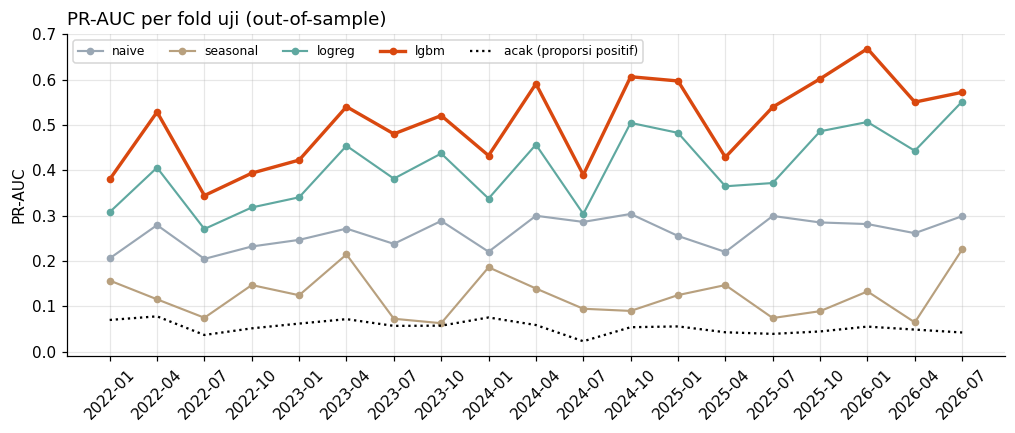

PR-AUC gabungan seluruh periode uji: {'naive': 0.256, 'seasonal': 0.114, 'logreg': 0.398, 'lgbm': 0.501}


In [6]:
models = ["naive", "seasonal", "logreg", "lgbm"]
pf = pred.groupby("fold").apply(lambda g: pd.Series({m: pr_auc(g["y"], g[f"score_{m}"]) for m in models} | {"proporsi_positif": g["y"].mean()}))
pf["mulai_uji"] = info.set_index("fold")["test_start"].dt.strftime("%Y-%m")
display(pf.set_index("mulai_uji").round(3))
fig, ax = plt.subplots(figsize=(11, 3.8))
for m in models:
    ax.plot(pf["mulai_uji"], pf[m], marker="o", ms=4, label=m, color=MODEL_COLORS[m], lw=2.2 if m == "lgbm" else 1.4)
ax.plot(pf["mulai_uji"], pf["proporsi_positif"], ls=":", color="k", label="acak (proporsi positif)")
ax.set_ylabel("PR-AUC"); ax.tick_params(axis="x", rotation=45); ax.legend(ncol=5, fontsize=8)
ax.set_title("PR-AUC per fold uji (out-of-sample)", loc="left")
fig.savefig(P.figures / "fig_05_02_prauc_per_fold.png", dpi=160, bbox_inches="tight"); plt.show()
print("PR-AUC gabungan seluruh periode uji:", {m: round(pr_auc(pred["y"], pred[f"score_{m}"]), 3) for m in models})

## 5.4 Baseline SARIMA (subset komoditas volatil)
SARIMA dilatih **per seri** (tidak global), jadi mahal. Dipakai pada 5 varian paling relevan × 34 provinsi, origin **mingguan (Jumat)**. Perbandingan dengan model lain dilakukan pada baris yang sama persis (notebook 06).

In [7]:
RUN_SARIMA = cfg["model"]["sarima"]["enabled"]
if RUN_SARIMA:
    Pc = load_panel(P.processed / "panel_pt1.parquet")
    thr = threshold_per_column(Pc.columns, refs["c2cat"], cfg)
    sc = cfg["model"]["sarima"]
    series = [c for c in Pc.columns if c[0] in sc["commodities"] and c[1] != 0]
    parts = []
    t0 = time.time()
    for f in folds.itertuples():
        s = sarima_fold_scores(Pc, series, thr, f.fit_end, f.val_start, f.test_end, tuple(sc["order"]), sc["fourier_k"], n_jobs=2)
        s["date"] = pd.to_datetime(s["date"])
        key = ["date", "commodity_id", "province_id"]
        v = s[(s["date"] >= f.val_start) & (s["date"] <= f.val_end)].merge(data[key + ["y"]], on=key)
        tt = s[(s["date"] >= f.test_start) & (s["date"] <= f.test_end)].copy()
        tt["thr_sarima"] = best_threshold(v["y"].to_numpy(), v["score_sarima"].to_numpy(), cfg["model"]["threshold_metric"])
        tt["fold"] = f.fold
        parts.append(tt)
        print(f"fold {f.fold:2d}: {len(tt):,} origin uji ({time.time() - t0:.0f} dtk)")
    sar = pd.concat(parts, ignore_index=True)
    sar.to_parquet(P.processed / "oof_sarima.parquet", index=False)
    print(f"SARIMA selesai: {len(sar):,} prediksi, {len(series)} seri, {(time.time() - t0) / 60:.1f} menit")

fold  0: 2,004 origin uji (16 dtk)


fold  1: 2,171 origin uji (30 dtk)


fold  2: 2,338 origin uji (44 dtk)


fold  3: 2,171 origin uji (58 dtk)


fold  4: 2,171 origin uji (72 dtk)


...

fold 14: 2,171 origin uji (241 dtk)


fold 15: 2,171 origin uji (259 dtk)


fold 16: 2,171 origin uji (278 dtk)


fold 17: 2,171 origin uji (296 dtk)


fold 18: 1,837 origin uji (314 dtk)
SARIMA selesai: 40,915 prediksi, 169 seri, 5.2 menit


## 5.5 Ablation: seberapa penting tiap kelompok sinyal?
LightGBM dilatih ulang **tanpa** satu kelompok fitur (walk-forward yang sama). Penurunan PR-AUC = kontribusi kelompok tersebut. Ini menguji langsung hipotesis proposal: sinyal **rantai pasok (margin produsen–konsumen)**, **tetangga**, **provinsi pemimpin**, **kalender**, dan **curah hujan**.

In [5]:
RUN_ABLATION = cfg["model"]["ablation"]["enabled"]
unknown = [g for g in cfg["model"]["ablation"]["groups"] if g not in set(groups.values())]
assert not unknown, f"Kelompok ablation tidak dikenal: {unknown}. Pilihan: {sorted(set(groups.values()))}"
variants = {f"tanpa {g}": [g] for g in cfg["model"]["ablation"]["groups"]}
variants["tanpa tetangga & pemimpin (tanpa sinyal spasial)"] = ["tetangga", "pemimpin"]
variants["hanya harga sendiri + identitas"] = [g for g in set(groups.values()) if g not in ("harga", "identitas")]
abl = pred[["date", "commodity_id", "province_id", "y", "fold", "score_lgbm"]].rename(columns={"score_lgbm": "semua fitur"})
if RUN_ABLATION:
    for name, drop in variants.items():
        cols = feature_columns(data, groups, exclude_groups=tuple(drop))
        t0 = time.time()
        pr_, _ = run_walk_forward(data, cols, cfg, folds=folds, use_models=("lgbm",), lgbm_params=params, verbose=False)
        abl[name] = pr_["score_lgbm"].to_numpy()
        print(f"{name:52s} fitur={len(cols):3d}  PR-AUC={pr_auc(pr_['y'], pr_['score_lgbm']):.4f}  ({time.time() - t0:.0f} dtk)")
    abl.to_parquet(P.processed / "oof_ablation.parquet", index=False)

tanpa rantai_pasok                                   fitur= 60  PR-AUC=0.5045  (773 dtk)


tanpa tetangga                                       fitur= 73  PR-AUC=0.4970  (710 dtk)


tanpa pemimpin                                       fitur= 75  PR-AUC=0.4952  (673 dtk)


tanpa kalender                                       fitur= 65  PR-AUC=0.4715  (494 dtk)


tanpa cuaca                                          fitur= 68  PR-AUC=0.5002  (539 dtk)


tanpa tetangga & pemimpin (tanpa sinyal spasial)     fitur= 70  PR-AUC=0.4767  (597 dtk)


hanya harga sendiri + identitas                      fitur= 23  PR-AUC=0.4363  (260 dtk)


## 5.6 Penilaian model (ringkas)
Evaluasi lengkap (FAR, lead time, per komoditas, SHAP, kriteria sukses) ada di notebook 06. Di sini cek cepat: stabilitas antar-fold & jumlah pohon terbaik.

In [9]:
display(info[["fold", "test_start", "n_fit", "n_test", "pos_test", "lgbm_best_iter", "thr_lgbm", "seconds"]])
stab = pf[models].agg(["mean", "std", "min", "max"]).T
stab["fold_menang_vs_naive"] = [(pf[m] > pf["naive"]).mean() for m in models]
display(stab.round(3))

,fold,test_start,n_fit,n_test,pos_test,lgbm_best_iter,thr_lgbm,seconds
0,0,2022-01-01,576319,41342,0.0700,175,0.2610,31.2000
1,1,2022-04-01,619414,40978,0.0779,125,0.1815,26.6000
2,2,2022-07-01,661022,44084,0.0369,254,0.1956,35.3000
3,3,2022-10-01,702998,43524,0.0515,140,0.1889,30.0000
4,4,2023-01-01,745107,42414,0.0620,242,0.3304,39.2000
5,5,2023-04-01,788361,42996,0.0718,228,0.2166,39.0000
6,6,2023-07-01,831185,43026,0.0569,258,0.2892,43.3000
7,7,2023-10-01,874476,41276,0.0574,231,0.2492,41.7000
8,8,2024-01-01,917581,41882,0.0755,81,0.2058,31.2000
9,9,2024-04-01,959673,42746,0.0588,314,0.2417,61.5000


,mean,std,min,max,fold_menang_vs_naive
naive,0.2620,0.0340,0.2050,0.3040,0.0000
seasonal,0.1230,0.0490,0.0630,0.2260,0.0000
logreg,0.4070,0.0810,0.2710,0.5520,1.0000
lgbm,0.5050,0.0940,0.3440,0.6680,1.0000


### Ringkasan fase 4
- 5 pendekatan dibandingkan dengan desain uji yang sama (walk-forward + purge), tanpa menyentuh data uji saat tuning.
- Prediksi out-of-sample disimpan: `oof_predictions.parquet`, `oof_sarima.parquet`, `oof_ablation.parquet`.

➡️ Lanjut ke **`06_evaluation.ipynb`**.